# About Dataset

## Content:

The data belongs to Lloyds Banking, the largest retail bank in the uk. 

This dataset consists of 18,324 customers who:  

➢ Previously held a loan  

➢ The status of that loan- did the customer pay back the loan or not:  
- Customers who paid back are categorised as 'Fully Paid'  
- Customers who did not pay back their loan are categorised as 'Charged-off'  

➢ Other credit and product information that can be used to understand a customer's credit or financial behaviour

## Task

The objective of this task is the create a model predicting the likelihood of a customer paying back their loan


To make this appropriate for a Jupyter Notebook, you should present this information in a **Markdown cell** at the beginning of your project. This provides clear documentation for anyone viewing your notebook.

You can copy and paste the following block directly into a Markdown cell in your Jupyter Notebook:

```markdown
# Project: Loan Default Prediction

## 1. About the Dataset
This dataset consists of 18,324 customers from Lloyds Banking, the largest retail bank in the UK. The goal is to analyze past loan performance to predict the likelihood of future defaults.

*   **Fully Paid**: Customer successfully paid back the loan.
*   **Charged-off**: Customer failed to pay back the loan.

## 2. Task Objective
Create a predictive model to determine the likelihood of a customer paying back their loan.

## 3. Data Dictionary
| Column | Type | Description |
| :--- | :--- | :--- |
| `id` | Identifier | Unique ID for the loan listing. |
| `addr_state` | Categoric | US state of the borrower. |
| `annual_inc` | Numeric | Annual income provided at registration. |
| `emp_length` | Categoric | Employment length (0-10 years). |
| `emp_title` | Categoric | Job title of the borrower. |
| `home_ownership` | Categoric | Status (RENT, OWN, MORTGAGE, OTHER). |
| `installment` | Numeric | Monthly payment amount. |
| `loan_amnt` | Numeric | Total loan amount applied for. |
| `purpose` | Categoric | Reason for the loan. |
| `term` | Categoric | Loan duration (36 or 60 months). |
| `int_rate` | Numeric | Interest rate. |
| `avg_cur_bal` | Numeric | Average balance of all credit products. |
| `inq_last_12m` | Numeric | Number of credit inquiries in past 12 months. |
| `max_bal_bc` | Numeric | Max balance owed on revolving accounts. |
| `mo_sin_old_il_acct` | Numeric | Months since oldest installment account opened. |
| `mo_sin_old_rev_tl_op` | Numeric | Months since oldest revolving account opened. |
| `mo_sin_rcnt_rev_tl_op`| Numeric | Months since most recent revolving account opened. |
| `mo_sin_rcnt_tl` | Numeric | Months since most recent account opened. |
| `mort_acc` | Numeric | Number of mortgage accounts. |
| `mths_since_last_delinq`| Numeric | Months since last missed payment. |
| `num_bc_tl` | Numeric | Number of bankcard accounts. |
| `num_il_tl` | Numeric | Number of installment accounts. |
| `num_op_rev_tl` | Numeric | Number of open revolving accounts. |
| `num_tl_90g_dpd_24m` | Numeric | Number of accounts 90+ days past due in 24 months. |
| `num_tl_op_past_12m` | Numeric | Number of accounts past due in 12 months. |
| `open_acc` | Numeric | Number of open credit lines. |
| `percent_bc_gt_75` | Numeric | Percentage of bankcard accounts > 75% limit. |
| `pub_rec_bankruptcies`| Numeric | Number of public record bankruptcies. |
| `total_acc` | Numeric | Total number of credit lines. |
| `total_bal_ex_mort` | Numeric | Total balance excluding mortgage. |
| `loan_status` | Target | Status (Fully Paid / Charged-off). |

```

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import  cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from feature_engine.outliers import Winsorizer
from sklearn.compose import ColumnTransformer
import optuna
import mlflow
from mlflow.models import infer_signature



e:\Projects\Lloyd Bank\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base_path = Path.cwd().parent/"data"/"raw"
file_path = base_path/"LBG Step Up Data Set.xlsx"
df = pd.read_excel(file_path)
print(f'Number of rows: {df.shape[0]} \nnumber of columns: {df.shape[1]}')

Number of rows: 18324 
number of columns: 31


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [4]:
df.head()

,id,addr_state,annual_inc,emp_length,emp_title,home_ownership,installment,loan_amnt,purpose,term,int_rate,avg_cur_bal,inq_last_12m,max_bal_bc,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_last_delinq,num_bc_tl,num_il_tl,num_op_rev_tl,num_tl_90g_dpd_24m,num_tl_op_past_12m,open_acc,percent_bc_gt_75,pub_rec_bankruptcies,total_acc,total_bal_ex_mort,loan_status
0,802173,CA,72000.0,3 years,CA. Dept. Of Corrections,MORTGAGE,395.66,12000,debt_consolidation,36 months,0.1149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,0,23,NaN,Fully Paid
1,14518910,TX,97500.0,1 year,Curriculum & Implementation Manager,RENT,966.47,35000,debt_consolidation,60 months,0.2199,7019.0,NaN,NaN,148.0,170.0,28.0,9.0,4.0,NaN,14.0,2.0,12.0,0.0,1.0,13,87.5,0,24,84227.0,Fully Paid
2,54333324,NY,120000.0,1 year,Senior manager,RENT,806.57,25000,credit_card,36 months,0.0999,4891.0,NaN,NaN,128.0,147.0,80.0,11.0,0.0,53.0,11.0,2.0,7.0,0.0,1.0,8,100.0,0,16,39124.0,Fully Paid
3,62247022,CA,130000.0,10+ years,Border Patrol Agent,RENT,846.17,25225,debt_consolidation,36 months,0.1269,17619.0,NaN,NaN,130.0,172.0,68.0,2.0,4.0,41.0,9.0,9.0,3.0,0.0,2.0,8,50.0,0,24,123331.0,Fully Paid
4,71986114,TX,58296.0,10+ years,Account Manager,MORTGAGE,41.79,1200,other,36 months,0.1531,12321.0,1.0,10372.0,167.0,145.0,18.0,18.0,1.0,NaN,7.0,7.0,6.0,0.0,0.0,9,100.0,0,17,51794.0,Fully Paid


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18324 entries, 0 to 18323
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      18324 non-null  int64  
 1   addr_state              18324 non-null  object 
 2   annual_inc              18324 non-null  float64
 3   emp_length              17150 non-null  object 
 4   emp_title               17042 non-null  object 
 5   home_ownership          18324 non-null  object 
 6   installment             18324 non-null  float64
 7   loan_amnt               18324 non-null  int64  
 8   purpose                 18324 non-null  object 
 9   term                    18324 non-null  object 
 10  int_rate                18324 non-null  float64
 11  avg_cur_bal             17758 non-null  float64
 12  inq_last_12m            9395 non-null   float64
 13  max_bal_bc              9395 non-null   float64
 14  mo_sin_old_il_acct      17192 non-null

In [6]:
df.describe()

,id,annual_inc,installment,loan_amnt,int_rate,avg_cur_bal,inq_last_12m,max_bal_bc,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_last_delinq,num_bc_tl,num_il_tl,num_op_rev_tl,num_tl_90g_dpd_24m,num_tl_op_past_12m,open_acc,percent_bc_gt_75,pub_rec_bankruptcies,total_acc,total_bal_ex_mort
count,1.832400e+04,1.832400e+04,18324.000000,18324.000000,18324.000000,17758.000000,9395.000000,9395.000000,17192.000000,17760.000000,17760.000000,17760.000000,17926.000000,9276.000000,17760.000000,17760.000000,17760.000000,17760.000000,17760.000000,18324.000000,17714.000000,18324.000000,18324.000000,1.792600e+04
mean,6.832645e+07,8.017611e+04,467.543006,15522.661537,0.138507,13466.600011,2.301863,5728.533475,125.348127,180.750788,13.077534,7.793131,1.626799,34.364705,7.964752,8.575619,8.268525,0.086092,2.274775,11.629284,45.489228,0.142054,24.750109,5.148915e+04
std,4.245703e+07,6.487345e+04,278.099801,9349.294243,0.048223,16550.730832,2.523087,5628.027589,52.996782,95.122321,16.500588,8.911026,1.993844,22.047538,4.847990,7.372691,4.627181,0.440718,1.936068,5.578496,35.907408,0.388198,12.192517,4.970348e+04
min,3.009180e+05,3.000000e+03,30.650000,1000.000000,0.053100,0.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000e+00
25%,3.491424e+07,4.700000e+04,259.302500,8000.000000,0.104900,3129.000000,1.000000,2170.500000,97.000000,116.000000,4.000000,3.000000,0.000000,16.000000,4.000000,3.000000,5.000000,0.000000,1.000000,8.000000,12.500000,0.000000,16.000000,2.151850e+04
50%,6.838023e+07,6.500000e+04,397.480000,14000.000000,0.133300,7137.000000,2.000000,4244.000000,129.000000,164.000000,8.000000,5.000000,1.000000,31.000000,7.000000,7.000000,7.000000,0.000000,2.000000,11.000000,44.400000,0.000000,23.000000,3.897700e+04
75%,9.730784e+07,9.500000e+04,635.720000,21000.000000,0.169900,18436.500000,3.000000,7357.000000,152.000000,231.000000,16.000000,10.000000,3.000000,50.000000,10.000000,11.000000,11.000000,0.000000,3.000000,14.000000,75.000000,0.000000,32.000000,6.526700e+04
max,1.708249e+08,2.616000e+06,1503.890000,40000.000000,0.309900,341236.000000,28.000000,99609.000000,530.000000,674.000000,182.000000,135.000000,29.000000,115.000000,45.000000,78.000000,49.000000,10.000000,22.000000,50.000000,100.000000,6.000000,110.000000,1.501187e+06


- based on the .describe, we can see that some categorical variables have large number of categories like the `addr_state`
- for those that only have 2 (binary) let's just replace by 0 and 1 
- for those that have more than 2, we will use one-hot encode them or drop them

In [7]:
def missing_values(data: pd.DataFrame) -> pd.DataFrame:
    """
    Analyzes missing data in a DataFrame and returns a summary.

    Args:
        data (pd.DataFrame): The input DataFrame to analyze.

    Returns:
        pd.DataFrame: A DataFrame containing 'missing_perc', 'unique_values', 
                      and 'col_type' for columns with missing values, 
                      sorted by 'missing_perc' in descending order.
    """
    missing_perc = round(data.isna().mean() * 100, 2)
    unique_values = data.nunique()
    col_type = data.dtypes

    summary_df = pd.DataFrame({
        'missing_perc' : missing_perc,
        'unique_values' : unique_values,
        'col_type' : col_type
    })
    return summary_df[summary_df['missing_perc'] > 0.0].sort_values(by='missing_perc', ascending=False)


missing_values(data=df)

,missing_perc,unique_values,col_type
mths_since_last_delinq,49.38,98,float64
inq_last_12m,48.73,25,float64
max_bal_bc,48.73,6440,float64
emp_title,7.00,10040,object
emp_length,6.41,11,object
mo_sin_old_il_acct,6.18,355,float64
percent_bc_gt_75,3.33,111,float64
avg_cur_bal,3.09,12635,float64
mo_sin_old_rev_tl_op,3.08,564,float64
mo_sin_rcnt_rev_tl_op,3.08,150,float64


We observed that `mths_since_last_delinq`, `inq_last_12m`, and `max_bal_bc` are missing nearly 50% of their data; these columns may be excluded from the model. The remaining features show significantly lower missingness (under 10%), allowing for more robust imputation  


Next, will check for outliers.

In [8]:
def outliers(data: pd.DataFrame) -> pd.DataFrame:
    numerical_cols = data.select_dtypes(include=[int, float]).columns.tolist()
    results = []
    for col in numerical_cols:
        q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        IQR = q3 - q1
        lower, upper = q1 - (1.5 * IQR) , q3 + (IQR * 1.5)
        outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        perc_outliers = round(outliers / len(data) * 100, 2)
        results.append({
            'column' : col,
            'outliers' : outliers,
            'perc_outliers' : perc_outliers,
            'lower_bound' : lower,
            'upper_bound' : upper

        })
    return pd.DataFrame(results).sort_values(by='perc_outliers', ascending=False)

outliers_df = outliers(data=df)
outliers_df

,column,outliers,perc_outliers,lower_bound,upper_bound
21,pub_rec_bankruptcies,2410,13.15,0.000000e+00,0.000000e+00
10,mo_sin_rcnt_rev_tl_op,1328,7.25,-1.400000e+01,3.400000e+01
17,num_tl_90g_dpd_24m,1042,5.69,0.000000e+00,0.000000e+00
23,total_bal_ex_mort,1034,5.64,-4.410425e+04,1.308898e+05
5,avg_cur_bal,1030,5.62,-1.983225e+04,4.139775e+04
11,mo_sin_rcnt_tl,1028,5.61,-7.500000e+00,2.050000e+01
1,annual_inc,1007,5.50,-2.500000e+04,1.670000e+05
15,num_il_tl,852,4.65,-9.000000e+00,2.300000e+01
8,mo_sin_old_il_acct,831,4.54,1.450000e+01,2.345000e+02
19,open_acc,682,3.72,-1.000000e+00,2.300000e+01


`pub_rec_bankruptcies` shows the most outliers, but as a binary feature, these are expected and can be ignored. For other numeric columns, we will evaluate the underlying distributions to decide between applying data transformations or winsorizing

In [9]:
# Drop id column
df = df.drop(columns=['id'])

# EDA

First, we will inspect the distributions of numerical columns with missing data to decide between imputation and transformation strategies

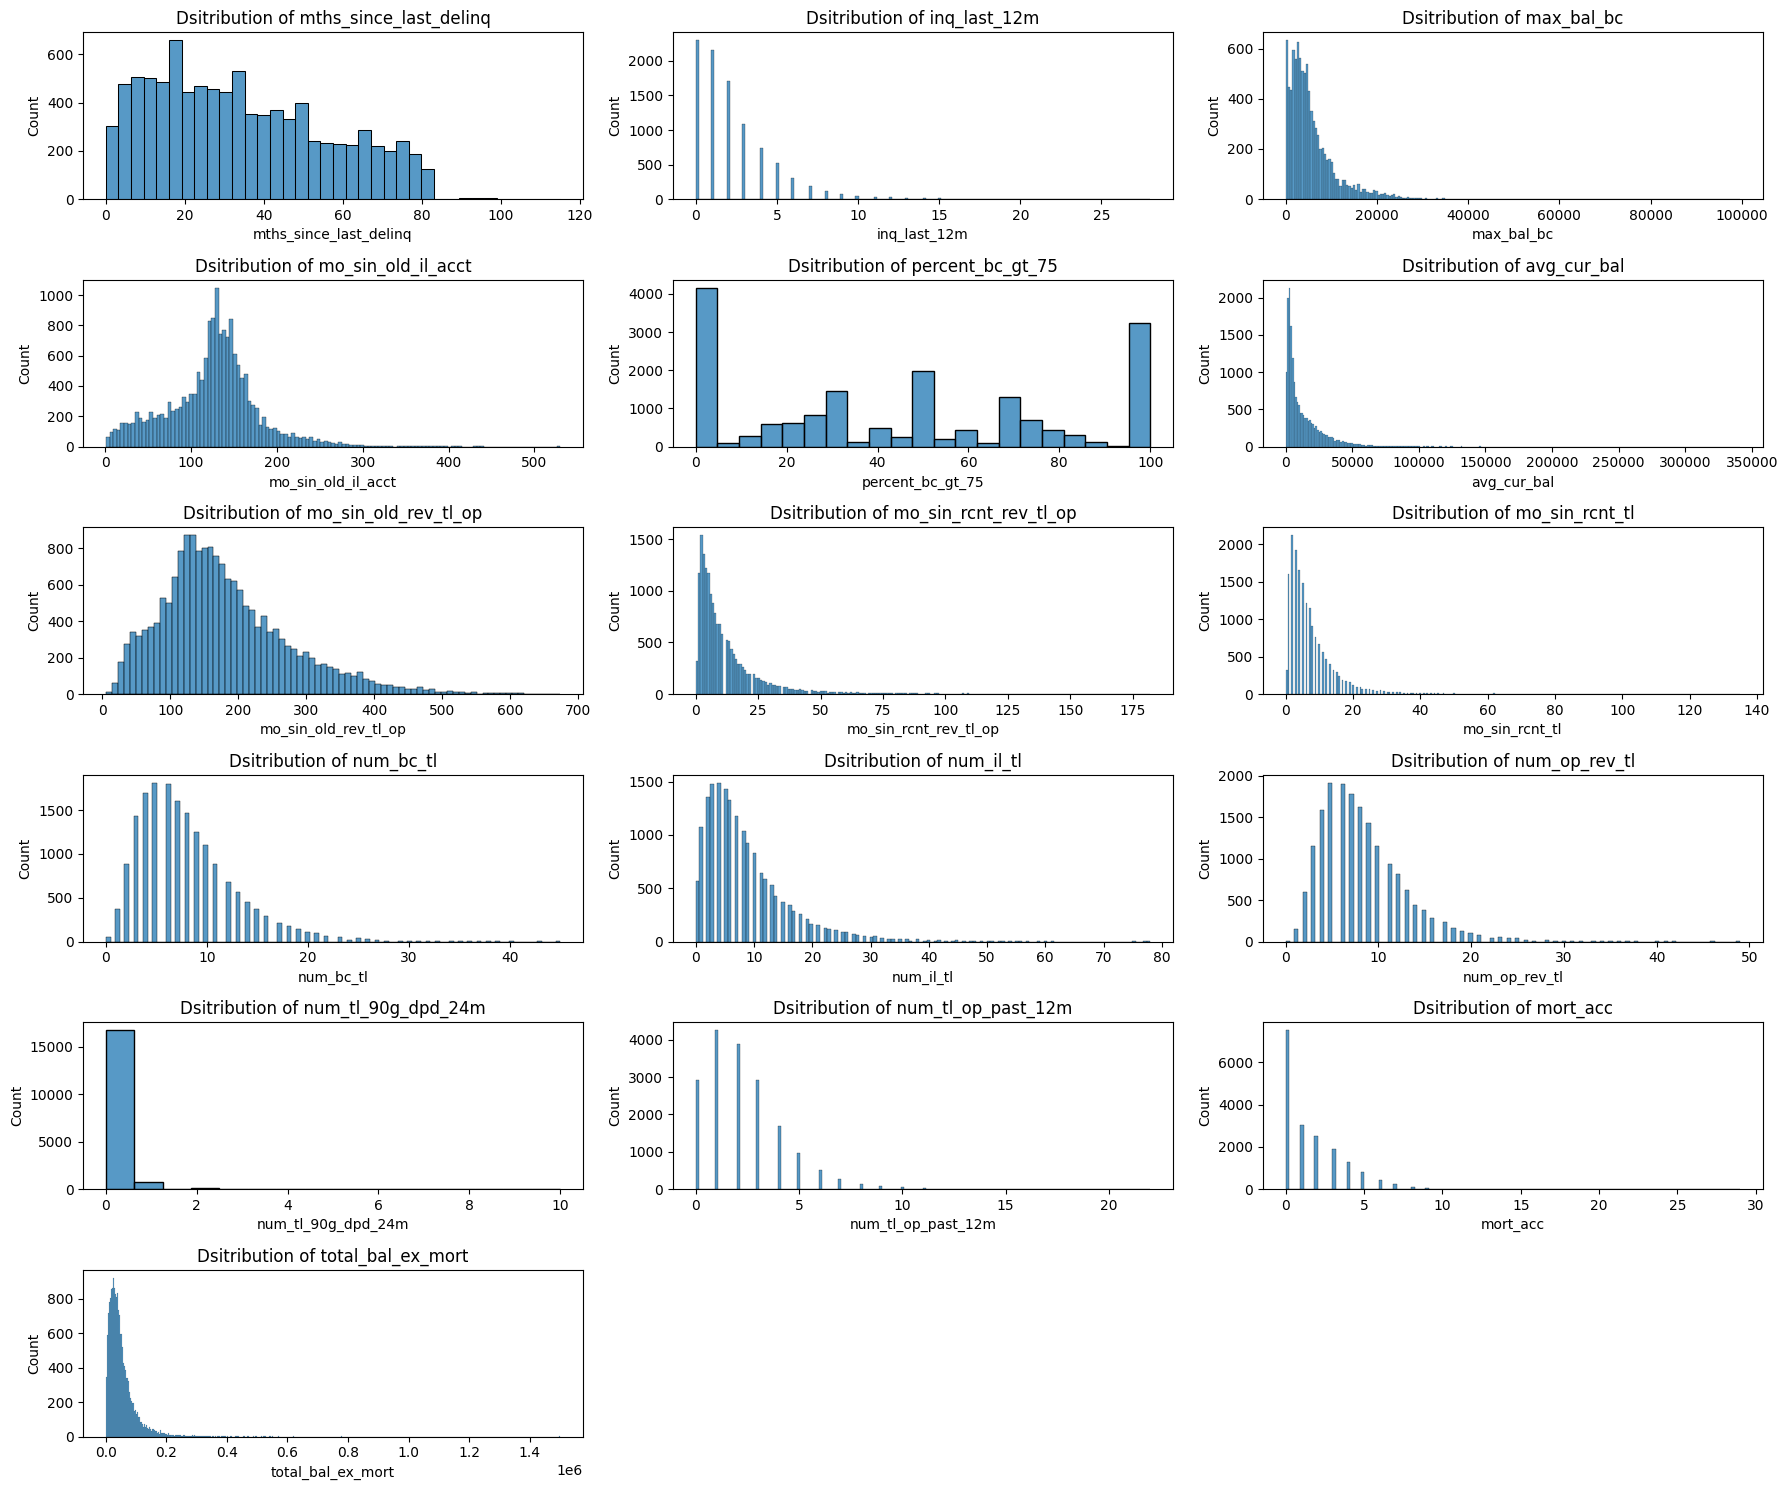

In [10]:
missing_cols = missing_values(data=df).reset_index().rename(columns={'index' : 'cols'})
numerical_missing_cols = missing_cols[missing_cols['col_type'] == float]['cols'].tolist()


fig, axs = plt.subplots(nrows= math.ceil(len(numerical_missing_cols) / 3), ncols=3, figsize=(18,15))
axs = axs.flatten()


for index, col in enumerate(numerical_missing_cols):
    sns.histplot(data=df[col], ax=axs[index])
    axs[index].set_title(f'Dsitribution of {col}')

for i in range(len(numerical_missing_cols), len(axs)):
    axs[i].set_visible(False)

plt.tight_layout()
plt.show()



Due to the right-skewed nature of the data, the mean is not a suitable imputation metric. Instead, we will utilize `IterativeImputer` to provide more accurate estimates. For features with high missingness, we will introduce binary indicator variables to flag missing entries, allowing our models to learn from the absence of data.

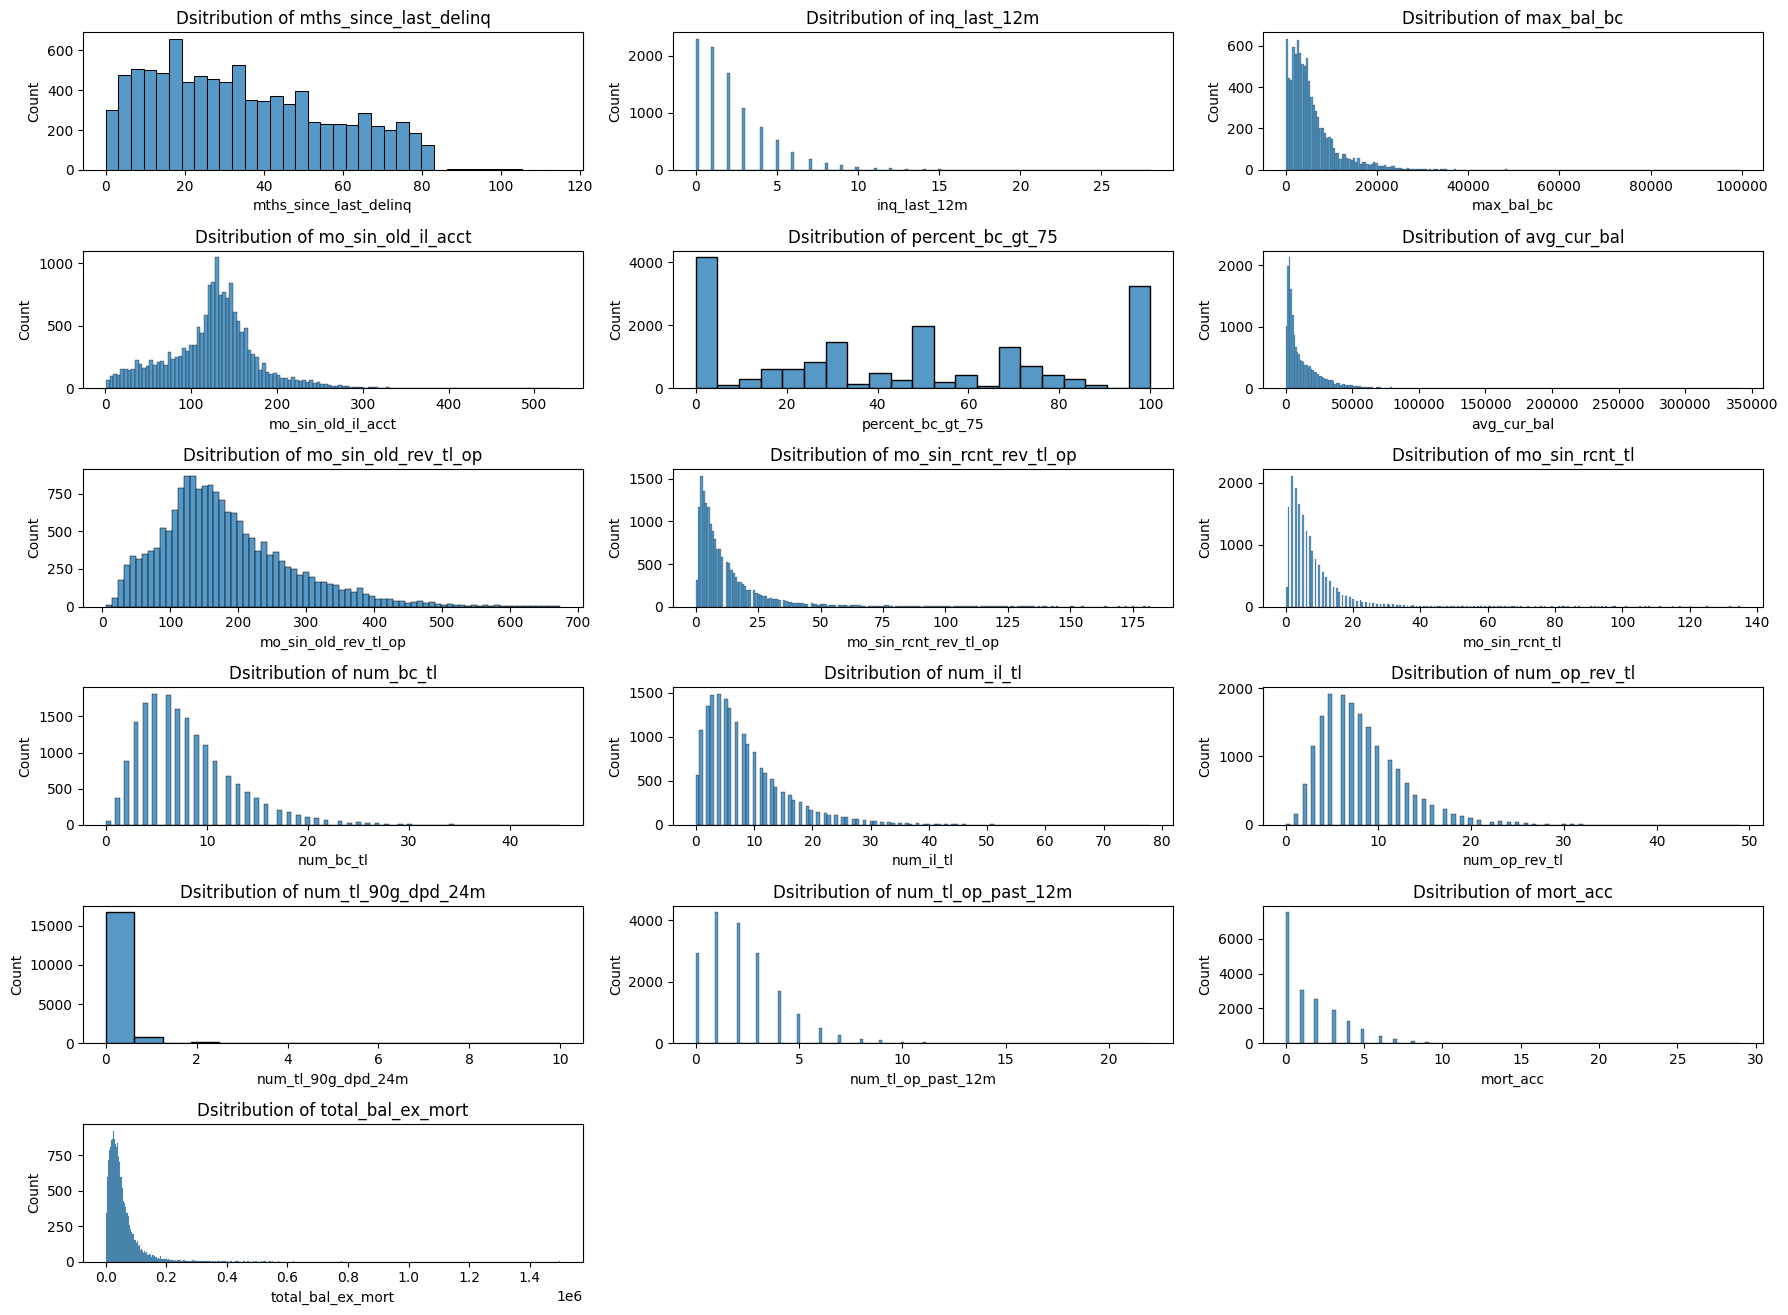

In [11]:
outliers_df = outliers(data=df)
outliers_df = outliers_df[outliers_df['outliers'] > 0]
outliers_cols = outliers_df['column'][1:].tolist()




fig, axs = plt.subplots(nrows= math.ceil(len(outliers_cols) / 3), ncols=3, figsize=(18,15))
axs = axs.flatten()


for index, col in enumerate(numerical_missing_cols):
    sns.histplot(data=df[col], ax=axs[index])
    axs[index].set_title(f'Dsitribution of {col}')

for i in range(len(numerical_missing_cols), len(axs)):
    axs[i].set_visible(False)

plt.tight_layout()
plt.show()

Looking at these distributions, almost everything here is right-skewed count or monetary data.

Based on the observed distributions and the underlying nature of the data, the following columns are primary candidates for transformation: `total_bal_ex_mort`, `max_bal_bc`, `avg_cur_bal`, `mo_sin_rcnt_rev_tl_op`, and `mo_sin_rcnt_tl`.



## Univariate Analysis

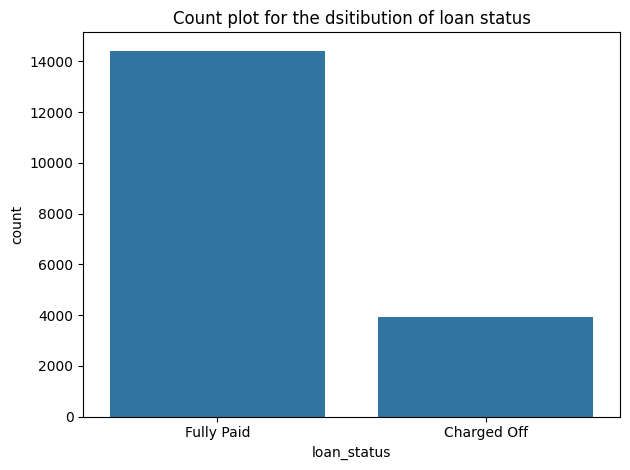

In [12]:
sns.countplot(x=df['loan_status'])
plt.title("Count plot for the dsitibution of loan status")
plt.tight_layout()
plt.show()


In [13]:
ratio = (df['loan_status'] == 'Fully Paid').sum() / (df['loan_status'] == 'Charged Off').sum()
print(f'Ratio of Fully Paid to Charged Off: {ratio:.2f} : 1')

Ratio of Fully Paid to Charged Off: 3.69 : 1


In [14]:
default_rate = (df['loan_status'] == 'Charged Off').mean()
print(f"Overall Default Rate: {default_rate:.2%}")

Overall Default Rate: 21.32%


The target distribution is highly imbalanced, showing a 3.7:1 ratio of 'Fully Paid' to 'Charged Off' loans. Given that only 21.32% of customers defaulted, we must account for this imbalance to prevent model bias toward the majority class

## Bivariate EDA

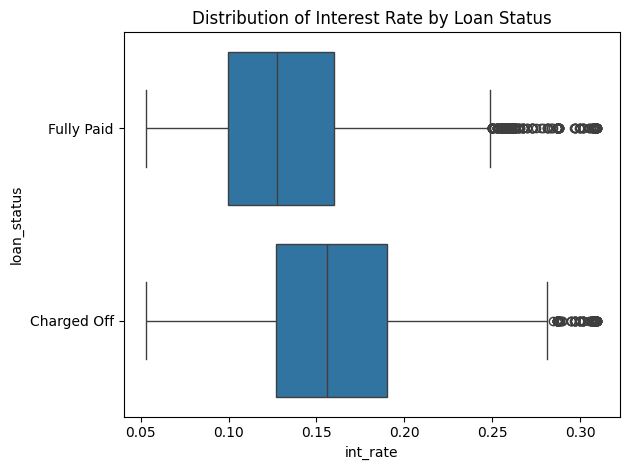

In [15]:
sns.boxplot(x=df['int_rate'], y=df['loan_status'])
plt.title('Distribution of Interest Rate by Loan Status')
plt.tight_layout()
plt.show()


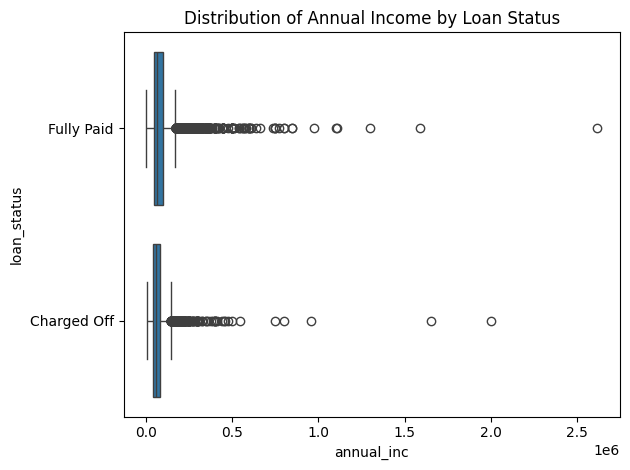

In [16]:
sns.boxplot(x=df['annual_inc'], y=df['loan_status'])
plt.title('Distribution of Annual Income by Loan Status')
plt.tight_layout()
plt.show()


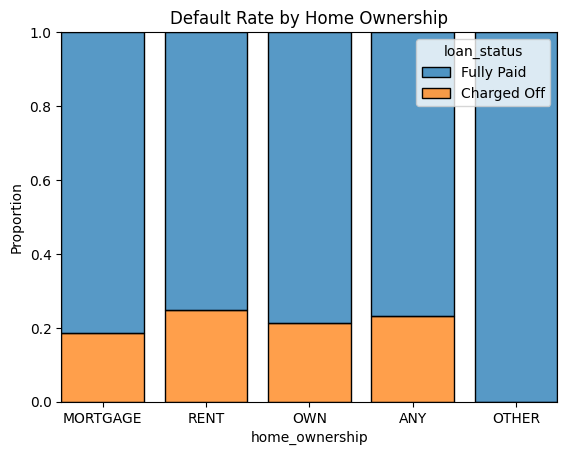

In [17]:
sns.histplot(
    data=df, 
    x='home_ownership', 
    hue='loan_status', 
    stat="proportion",
    multiple='fill',
    shrink=.8
)

plt.title('Default Rate by Home Ownership')
plt.show()

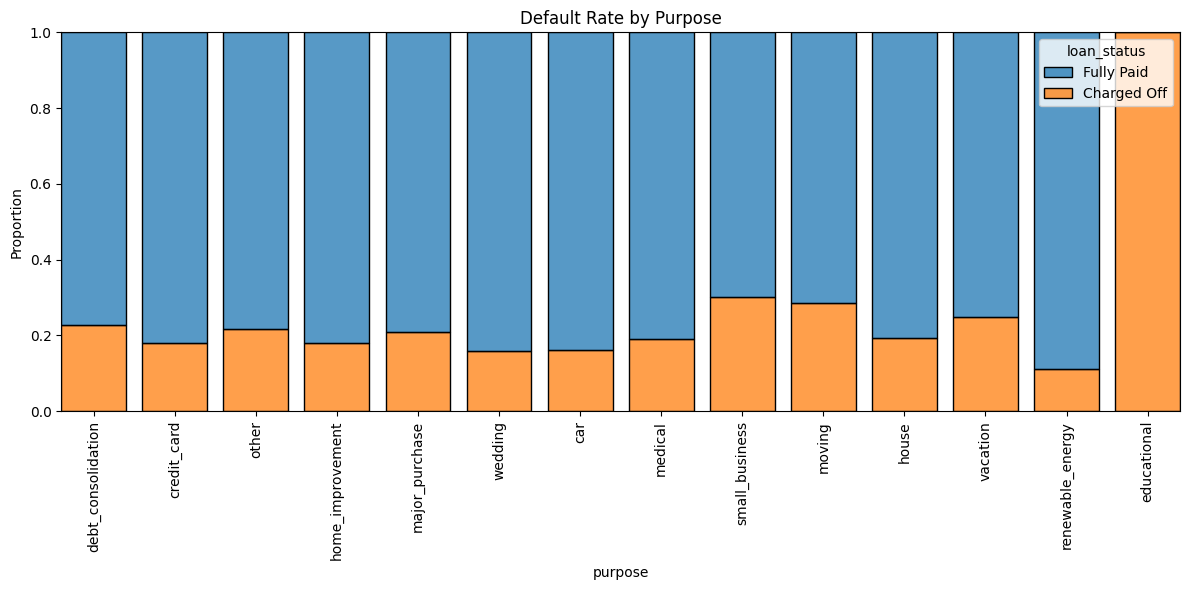

In [18]:
plt.figure(figsize=(12,6))
sns.histplot(data=df,
             x='purpose',
             hue='loan_status',
             stat='proportion',
             multiple='fill',
             shrink=.8)

plt.title('Default Rate by Purpose')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Summary: 
- Interest rate serves as a strong predictor of default. We observe that 'Charged Off' loans exhibit higher average interest rates, with their first quartile overlapping the mean of the 'Fully Paid' group, indicating a clear separation between the two classes.
- Annual income distributions are highly similar between 'Fully Paid' and 'Charged Off' loans. The lack of distinct separation in medians or interquartile ranges indicates that this feature likely offers limited discriminative power for our classification models
- There is a notable difference in default rates based on home ownership. Specifically, customers who rent show a higher default frequency compared to those with a mortgage, indicating that this feature provides actionable insight into credit risk.
- The analysis of default rates by loan purpose reveals that 'Education' and 'Small Business' categories exhibit the highest risk profiles. Notably, the 'Education' category shows a significantly high default frequency, suggesting that loan purpose is a robust predictor that the model should leverage to distinguish between high and low-risk applicants

## Multivariate Analysis

In [19]:
df.head()

,addr_state,annual_inc,emp_length,emp_title,home_ownership,installment,loan_amnt,purpose,term,int_rate,avg_cur_bal,inq_last_12m,max_bal_bc,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_last_delinq,num_bc_tl,num_il_tl,num_op_rev_tl,num_tl_90g_dpd_24m,num_tl_op_past_12m,open_acc,percent_bc_gt_75,pub_rec_bankruptcies,total_acc,total_bal_ex_mort,loan_status
0,CA,72000.0,3 years,CA. Dept. Of Corrections,MORTGAGE,395.66,12000,debt_consolidation,36 months,0.1149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,0,23,NaN,Fully Paid
1,TX,97500.0,1 year,Curriculum & Implementation Manager,RENT,966.47,35000,debt_consolidation,60 months,0.2199,7019.0,NaN,NaN,148.0,170.0,28.0,9.0,4.0,NaN,14.0,2.0,12.0,0.0,1.0,13,87.5,0,24,84227.0,Fully Paid
2,NY,120000.0,1 year,Senior manager,RENT,806.57,25000,credit_card,36 months,0.0999,4891.0,NaN,NaN,128.0,147.0,80.0,11.0,0.0,53.0,11.0,2.0,7.0,0.0,1.0,8,100.0,0,16,39124.0,Fully Paid
3,CA,130000.0,10+ years,Border Patrol Agent,RENT,846.17,25225,debt_consolidation,36 months,0.1269,17619.0,NaN,NaN,130.0,172.0,68.0,2.0,4.0,41.0,9.0,9.0,3.0,0.0,2.0,8,50.0,0,24,123331.0,Fully Paid
4,TX,58296.0,10+ years,Account Manager,MORTGAGE,41.79,1200,other,36 months,0.1531,12321.0,1.0,10372.0,167.0,145.0,18.0,18.0,1.0,NaN,7.0,7.0,6.0,0.0,0.0,9,100.0,0,17,51794.0,Fully Paid


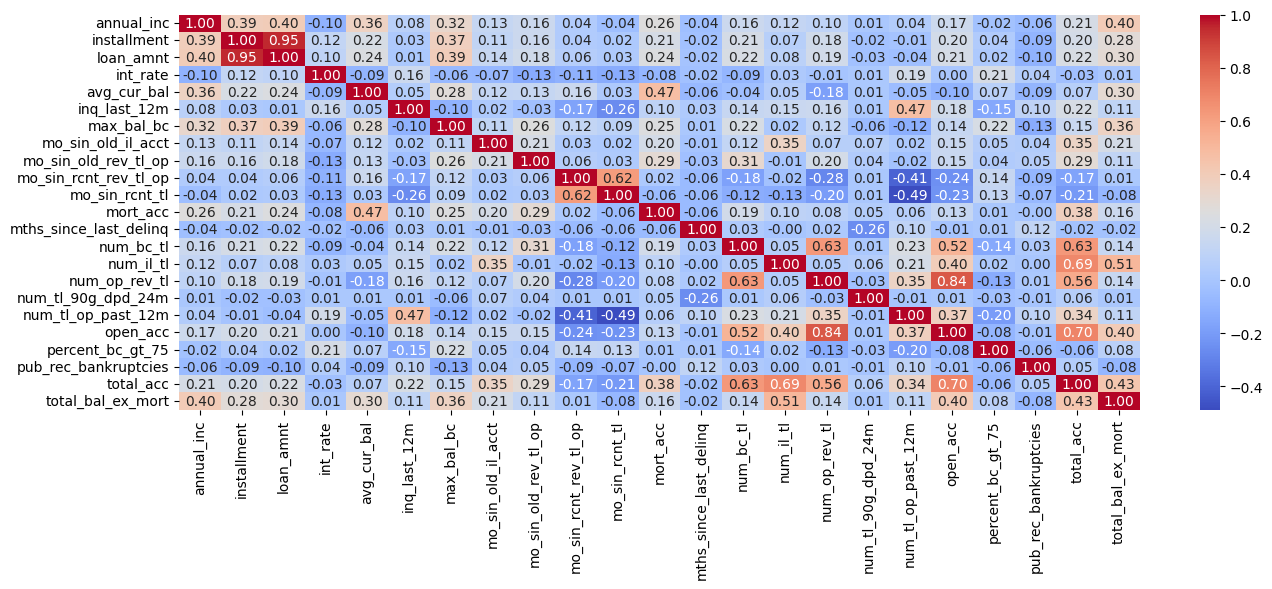

In [20]:
df_numerical_cols = df.select_dtypes(include=[int, float])
corr = df_numerical_cols.corr()

plt.figure(figsize=(14,6))
sns.heatmap(data=corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

The correlation heatmap highlights clear instances of multicollinearity within the dataset. Specifically, loan_amnt and installment exhibit a strong correlation of 0.95, while open_acc and total_acc show a correlation of 0.70. These high coefficients indicate significant feature redundancy; consequently, we will remove one variable from each pair to prevent model instability and potential overfitting.

# Data Preparation

In [21]:
# clean and transform Emp Length
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_map)

df = df.drop(columns=['emp_title', 'addr_state'])

In [22]:
loan_status = {'Charged Off': 1, 'Fully Paid': 0}


df['loan_status'] = df['loan_status'].map(loan_status)



# Prepare data
X = df.drop(columns=['loan_status'])
y = df['loan_status']


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model Building

In [24]:
one_hot_cols = ['home_ownership', 'purpose', 'term']
skewed_cols = ['total_bal_ex_mort', 'max_bal_bc', 'avg_cur_bal',
               'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl']
numerical_cols = X_train.select_dtypes(include=[int, float]).columns.tolist()
other_numeric_cols = [c for c in numerical_cols if c not in skewed_cols]

skewed_pipeline = Pipeline([
            ("impute", IterativeImputer(max_iter=10, random_state=42, skip_complete=True, min_value=0)),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("clip", Winsorizer(capping_method="quantiles", tail="both", fold=0.05)),
            ("scale", StandardScaler())
        ])
other_numeric_pipeline = Pipeline([
            ("impute", IterativeImputer(max_iter=10, random_state=42, skip_complete=True, min_value=0)),
            ("scale", StandardScaler())
        ])

preprocess = ColumnTransformer(transformers=[
            ("onehot", OneHotEncoder(drop='first', handle_unknown="ignore"), one_hot_cols),
            ("skewed_num", skewed_pipeline, skewed_cols),
            ("other_num", other_numeric_pipeline, other_numeric_cols)
        ])


In [25]:
def evaluate(true, predicted, proba):
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    auc = roc_auc_score(true, proba)
    precision = precision_score(true, predicted)
    return recall, f1, auc, precision


negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
ratio = negative_cases / positive_cases

models = {
    "LogisticRegression" : LogisticRegression(max_iter= 1000, class_weight='balanced', random_state=42),
    "RandomForestClassifier" : RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBClassifier" : XGBClassifier(scale_pos_weight=ratio, random_state=42)
}


def modelEvaluation(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test) -> pd.DataFrame:
    results = []
    for name, model in models.items():
        full_pipe = Pipeline(steps=[
            ("preprocess", preprocess),
            ('model', model)

        ])
        full_pipe.fit(X_train, y_train)

        y_pred = full_pipe.predict(X_test)
        y_proba = full_pipe.predict_proba(X_test)[:, 1]

        recall, f1, auc, precision = evaluate(true=y_test, predicted=y_pred, proba=y_proba)

        results.append({
            "model" : name,
            "recall" : recall,
            "f1": f1,
            'auc' : auc,
            'precision' : precision
        })
    return pd.DataFrame(results).sort_values(by='recall', ascending=False)

modelEvaluation()

,model,recall,f1,auc,precision
0,LogisticRegression,0.627401,0.438087,0.698966,0.336538
2,XGBClassifier,0.371319,0.342385,0.634365,0.317634
1,RandomForestClassifier,0.026889,0.050602,0.666128,0.428571


# Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [26]:
def objective(trial):
    
    params = {
        "C": trial.suggest_float("C", 1e-4, 10.0, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        "solver": "liblinear",
        "class_weight": "balanced",
        "max_iter": 1000,
        "random_state": 42
    }


    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):

        model = LogisticRegression(**params)
        pipe_lr = Pipeline(steps=[
            ('preprocess', preprocess), 
            ('classifier', model)
        ])

        
        cv_scores = cross_val_score(
            pipe_lr, X_train, y_train, 
            cv=5, scoring="recall", n_jobs=-1,
            error_score="raise"
        )
        
        avg_recall = cv_scores.mean()

        mlflow.log_params(params)
        mlflow.log_metrics({"recall": avg_recall})
    
    return avg_recall


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("loan_default_logreg_tuning")


with mlflow.start_run(run_name="logreg_optuna_search"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_recall", study.best_value)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

2026/07/12 17:54:15 INFO mlflow.tracking.fluent: Experiment with name 'loan_default_logreg_tuning' does not exist. Creating a new experiment.
[I 2026-07-12 17:54:16,539] A new study created in memory with name: no-name-58e2258f-6b43-494b-b744-e0b6712d0e01
[I 2026-07-12 17:54:24,305] Trial 0 finished with value: 0.6060800000000001 and parameters: {'C': 0.15196791837577575, 'penalty': 'l2'}. Best is trial 0 with value: 0.6060800000000001.


🏃 View run trial_0 at: http://127.0.0.1:5000/#/experiments/1/runs/96c1e897d08c4d2aa4fdd676a550ab0e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-07-12 17:54:29,158] Trial 1 finished with value: 0.65408 and parameters: {'C': 0.003982158759667632, 'penalty': 'l1'}. Best is trial 1 with value: 0.65408.


🏃 View run trial_1 at: http://127.0.0.1:5000/#/experiments/1/runs/5231759ca3024928b3fc4725eafee85e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-07-12 17:54:34,682] Trial 2 finished with value: 0.0 and parameters: {'C': 0.0004683015672518266, 'penalty': 'l1'}. Best is trial 1 with value: 0.65408.


...

🏃 View run trial_27 at: http://127.0.0.1:5000/#/experiments/1/runs/5f21c04e465f4662a993df93605aa36f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-07-12 17:55:24,015] Trial 28 finished with value: 0.6288 and parameters: {'C': 0.008202522273341046, 'penalty': 'l1'}. Best is trial 1 with value: 0.65408.


🏃 View run trial_28 at: http://127.0.0.1:5000/#/experiments/1/runs/5307afb9fcb5417a98652bb6831660f9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-07-12 17:55:25,036] Trial 29 finished with value: 0.60736 and parameters: {'C': 0.11322936292132234, 'penalty': 'l2'}. Best is trial 1 with value: 0.65408.


🏃 View run trial_29 at: http://127.0.0.1:5000/#/experiments/1/runs/e1c365e37782469ebe777949b263ac8f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run logreg_optuna_search at: http://127.0.0.1:5000/#/experiments/1/runs/f3a8a6f579c84178ad67b66b6cafa113
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Best Params: {'C': 0.003982158759667632, 'penalty': 'l1'}
Best Recall: 0.65408


In [27]:
# Re-initialize the model and the Pipeline
best_model = LogisticRegression(**study.best_params,solver="liblinear", class_weight="balanced", max_iter=1000, random_state=42)


pipe_lr = Pipeline(steps=[
            ('preprocess', preprocess), 
            ('model', best_model)
        ])

pipe_lr.fit(X_train, y_train)

# Prediction
proba = pipe_lr.predict_proba(X_test)[:, 1]
y_pred = pipe_lr.predict(X_test)

# Metrics
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
auc = roc_auc_score(y_test, proba)

print("Final tuned model performance:")
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print("auc:", auc)

# log final model
signature = infer_signature(X_train, pipe_lr.predict(X_train))

with mlflow.start_run(run_name="best_LR_model"):
    mlflow.log_params({**study.best_params, "solver": "liblinear",
                        "class_weight": "balanced"})
    mlflow.log_metrics({"precision": precision, "recall": recall, "f1": f1, "auc": auc})
    mlflow.sklearn.log_model(sk_model=pipe_lr, name="LR_Pipeline", registered_model_name='Best_loan_status_calssifier',
                              signature=signature, input_example=X_train)
    

e:\Projects\Lloyd Bank\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Projects\Lloyd Bank\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Final tuned model performance:
precision: 0.31101643335362145
recall: 0.6542893725992317
f1: 0.42161716171617164
auc: 0.6742751300388385


e:\Projects\Lloyd Bank\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
e:\Projects\Lloyd Bank\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization

🏃 View run best_LR_model at: http://127.0.0.1:5000/#/experiments/1/runs/93ff8a0ee3ab4334b183ba20c33ed8ff
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [28]:
serving_model_path = Path("../src/serving/model")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.artifacts.download_artifacts(
    artifact_uri="models:/Best_loan_status_calssifier/latest",
    dst_path=serving_model_path
)

'e:\\Projects\\Lloyd Bank\\src\\serving\\model\\'

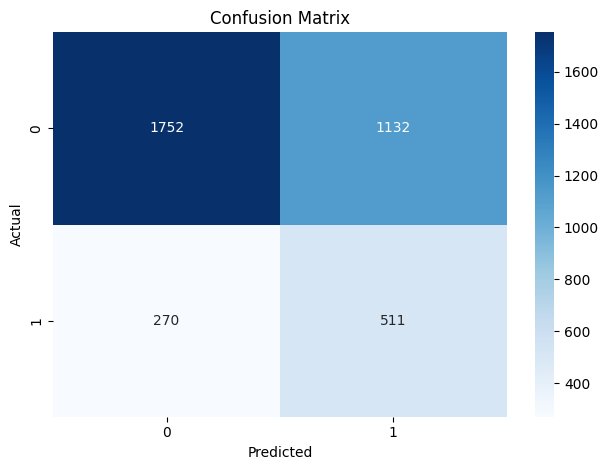

In [29]:
# Compute the confusion matrix 
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')



plt.tight_layout()
plt.show()